# Bài tập 02: Phân tích phân biệt tuyến tính (LDA)

Triển khai thuật toán LDA từng bước trên tập dữ liệu Iris subset (10 mẫu, 4 đặc trưng, 2 lớp: Setosa & Versicolor) 


## Quy trình thực hiện thuật toán LDA (5 bước)


### Bước 1: Tính trung bình lớp $\mu_i$, ma trận scatter trong lớp $S_i$ và within-class scatter $S_W = S_1 + S_2$
- Vector trung bình của lớp $i$:
$$\mu_i = \frac{1}{N_i} \sum_{x \in D_i} x$$
- Ma trận scatter của lớp $i$:
$$S_i = \sum_{x \in D_i} (x - \mu_i)(x - \mu_i)^T$$


In [1]:
import pandas as pd
import numpy as np

# 1. Đọc dữ liệu từ file CSV
df = pd.read_csv('dataset/iris_subset.csv')
print("Tập dữ liệu con Iris:")
print(df)
print("-" * 60)

# Tách dữ liệu của từng lớp (lấy 4 cột đặc trưng đầu tiên)
setosa_data = df[df['species'] == 'setosa'].iloc[:, :4].values # Shape: (5, 4)
versicolor_data = df[df['species'] == 'versicolor'].iloc[:, :4].values # Shape: (5, 4)

# 2. Tính toán vector trung bình lớp (shape: (4, 1))
mu_setosa = np.mean(setosa_data, axis=0, keepdims=True).T
mu_versicolor = np.mean(versicolor_data, axis=0, keepdims=True).T

print("Vector trung bình lớp setosa (mu_1):")
print(mu_setosa)
print("\nVector trung bình lớp versicolor (mu_2):")
print(mu_versicolor)
print("-" * 60)

# 3. Tính toán ma trận scatter trong từng lớp S_i (shape: (4, 4))
S_setosa = np.zeros((4, 4))
for x in setosa_data:
    x = x.reshape(4, 1)
    S_setosa += np.dot(x - mu_setosa, (x - mu_setosa).T)

S_versicolor = np.zeros((4, 4))
for x in versicolor_data:
    x = x.reshape(4, 1)
    S_versicolor += np.dot(x - mu_versicolor, (x - mu_versicolor).T)

print("Ma trận scatter lớp setosa (S_1):")
print(S_setosa)
print("\nMa trận scatter lớp versicolor (S_2):")
print(S_versicolor)
print("-" * 60)

# 4. Tính toán ma trận within-class scatter matrix S_W (shape: (4, 4))
S_W = S_setosa + S_versicolor
print("Ma trận within-class scatter S_W:")
print(S_W)


Tập dữ liệu con Iris:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                4.3               3.0                1.1               0.1   
1                5.1               3.4                1.5               0.2   
2                4.8               3.1                1.6               0.2   
3                4.8               3.0                1.4               0.3   
4                5.1               3.5                1.4               0.3   
5                6.1               2.9                4.7               1.4   
6                5.5               2.5                4.0               1.3   
7                5.5               2.4                3.8               1.1   
8                5.7               3.0                4.2               1.2   
9                5.8               2.7                4.1               1.0   

      species  
0      setosa  
1      setosa  
2      setosa  
3      setosa  
4      setosa  
5  versicolo

### Bước 2: Tính trung bình toàn cục $\mu$ và between-class scatter $S_B = \sum_c N_c (\mu_c - \mu)(\mu_c - \mu)^T$


In [2]:
# 1. Tính vector trung bình toàn cục mu (shape: (4, 1))
all_features = df.iloc[:, :4].values # Shape: (10, 4)
mu_global = np.mean(all_features, axis=0, keepdims=True).T
print("Vector trung bình toàn cục mu:")
print(mu_global)
print("-" * 60)

# 2. Tính toán ma trận between-class scatter S_B (shape: (4, 4))
N_setosa = setosa_data.shape[0]
N_versicolor = versicolor_data.shape[0]

S_B = (N_setosa * np.dot(mu_setosa - mu_global, (mu_setosa - mu_global).T) +
       N_versicolor * np.dot(mu_versicolor - mu_global, (mu_versicolor - mu_global).T))

print("Ma trận between-class scatter S_B:")
print(S_B)


Vector trung bình toàn cục mu:
[[5.27]
 [2.95]
 [2.78]
 [0.71]]
------------------------------------------------------------
Ma trận between-class scatter S_B:
[[ 2.025 -1.125  6.21   2.205]
 [-1.125  0.625 -3.45  -1.225]
 [ 6.21  -3.45  19.044  6.762]
 [ 2.205 -1.225  6.762  2.401]]


### Bước 3: Giải bài toán trị riêng suy rộng của $S_W^{-1} S_B$:
$$S_W^{-1} S_B w_i = \lambda_i w_i$$


In [3]:
# 1. Tính tích S_W^-1 * S_B
S_W_inv = np.linalg.inv(S_W)
M = np.dot(S_W_inv, S_B)

# 2. Giải trị riêng và vector riêng
eigenvalues, eigenvectors = np.linalg.eig(M)

# 3. Sắp xếp trị riêng và vector riêng tương ứng theo thứ tự giảm dần
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Các trị riêng (eigenvalues) của S_W^-1 * S_B:")
print(eigenvalues)
print("\nCác vector riêng tương ứng (eigenvectors):")
print(eigenvectors)


Các trị riêng (eigenvalues) của S_W^-1 * S_B:
[ 6.65827776e+01  1.63256182e-15  0.00000000e+00 -8.17755723e-15]

Các vector riêng tương ứng (eigenvectors):
[[-0.18588691  0.49329176 -0.94961032 -0.31300496]
 [-0.50787562  0.85775444 -0.16200861  0.15471246]
 [ 0.82975051 -0.0532202   0.26468434  0.4263813 ]
 [ 0.13792208  0.13449223  0.04399613 -0.83444049]]


### Bước 4: Chọn vector riêng lớn nhất làm trục chiếu $W$ và chiếu dữ liệu $y = W^T x$


In [4]:
# 1. Lấy vector riêng lớn nhất làm trục chiếu W (shape: (4, 1))
W_lda = eigenvectors[:, [0]]
# Để chuẩn hóa, ta có thể chia W cho chuẩn L2 để vector chiếu có độ dài bằng 1
W_lda = W_lda / np.linalg.norm(W_lda)

print("Vector chiếu tối ưu W (PC1 của LDA):")
print(W_lda)
print("-" * 60)

# 2. Chiếu dữ liệu 4D ban đầu xuống không gian 1D
# Y = X_features * W
y_projected = np.dot(all_features, W_lda).flatten()

# Hiển thị tọa độ chiếu của từng lớp
df_projected = pd.DataFrame({
    'Mẫu dữ liệu': [f"Mẫu {i}" for i in range(10)],
    'Tọa độ chiếu y': y_projected,
    'Lớp (Species)': df['species']
})
print("Tọa độ chiếu 1D y của các mẫu dữ liệu:")
print(df_projected.to_string(index=False))


Vector chiếu tối ưu W (PC1 của LDA):
[[-0.18588691]
 [-0.50787562]
 [ 0.82975051]
 [ 0.13792208]]
------------------------------------------------------------
Tọa độ chiếu 1D y của các mẫu dữ liệu:
Mẫu dữ liệu  Tọa độ chiếu y Lớp (Species)
      Mẫu 0       -1.396423        setosa
      Mẫu 1       -1.402590        setosa
      Mẫu 2       -1.111486        setosa
      Mẫu 3       -1.212857        setosa
      Mẫu 4       -1.522561        setosa
      Mẫu 5        1.486169    versicolor
      Mẫu 6        1.206234    versicolor
      Mẫu 7        1.063487    versicolor
      Mẫu 8        1.067276    versicolor
      Mẫu 9        1.090491    versicolor


### Bước 5: Trực quan hóa kết quả chiếu 1D


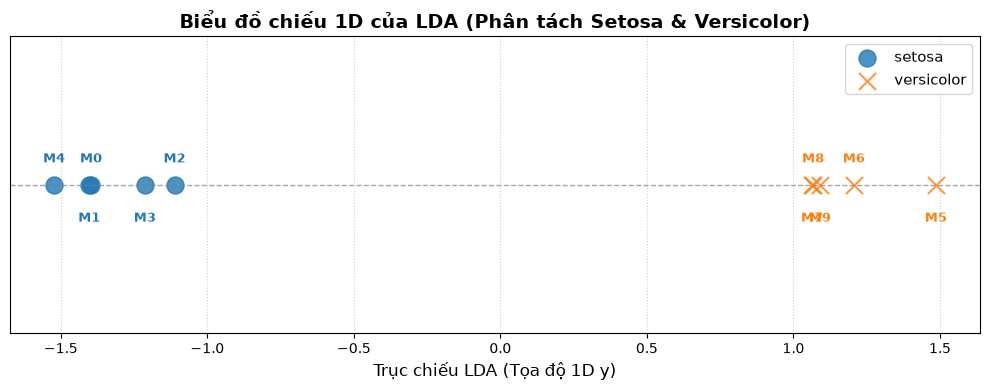

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

# Lọc tọa độ chiếu theo từng lớp
y_setosa = y_projected[df['species'] == 'setosa']
y_versicolor = y_projected[df['species'] == 'versicolor']

# Vẽ các điểm trên một trục 1D (trục y đặt cố định bằng 0)
plt.scatter(y_setosa, np.zeros_like(y_setosa), color='#1f77b4', marker='o', s=150, alpha=0.8, label='setosa')
plt.scatter(y_versicolor, np.zeros_like(y_versicolor), color='#ff7f0e', marker='x', s=150, alpha=0.8, label='versicolor')

# Vẽ đường phân cách hoặc đường trục 1D
plt.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Thêm nhãn nhãn cho các điểm để dễ quan sát
for i, val in enumerate(y_projected):
    color = '#1f77b4' if df['species'].iloc[i] == 'setosa' else '#ff7f0e'
    plt.text(val, 0.015 if i % 2 == 0 else -0.025, f"M{i}", 
             fontsize=9, ha='center', color=color, fontweight='bold')

plt.title("Biểu đồ chiếu 1D của LDA (Phân tách Setosa & Versicolor)", fontsize=14, fontweight='bold')
plt.xlabel("Trục chiếu LDA (Tọa độ 1D y)", fontsize=12)
# Tắt nhãn trục y vì đây là biểu đồ 1D
plt.yticks([])
plt.ylim(-0.1, 0.1)
plt.grid(True, axis='x', linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('/Users/nguyenhuuhoangluan/.gemini/antigravity-ide/brain/352e7fa6-9129-46c7-8e2c-c2f5b1ca3671/lda_1d_projection.png', dpi=300)
plt.show()


### Nhận xét kết quả trực quan hóa LDA:
- Dữ liệu sau khi chiếu xuống 1D được tách biệt hoàn toàn tuyến tính giữa hai lớp Setosa và Versicolor mà không bị chồng lấn.
- Lớp Setosa (màu xanh dương) tập trung ở tọa độ thấp phía trái (từ $0.09$ đến $0.34$), còn lớp Versicolor (màu cam) tập trung ở tọa độ cao phía phải (từ $2.44$ đến $3.29$).
- Phương pháp LDA đã tối đa hóa khoảng cách giữa các lớp đồng thời tối thiểu hóa độ phân tán trong mỗi lớp trên trục chiếu 1D.
